# Cereals 자료 — 왜 표준화가 필요한가, 그리고 PCA + 회귀

**자료**.  Cereals.csv — 77 종의 시리얼에 대한 영양 성분 13 개 + 소비자 등급(rating).

**목표**.  세 단계로 따라간다.

1. **표준화 없이 PCA** 를 돌리면 무슨 일이 벌어지는지 본다 — sodium 한 변수가 PC1 을 점령한다.
2. **표준화 후 PCA** 를 돌려서 모든 변수가 동등한 분산으로 시작하게 만든다.
3. **PC 점수를 새 설명변수로 써서 회귀** (Principal Component Regression, PCR) 를 실시한다 — 다중공선성 문제가 자연스럽게 풀린다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False

## 1. 자료 불러오기와 변수별 분산 비교

In [2]:
# Cereals 자료를 GitHub raw URL 에서 불러온다.
# 이 한 블록은 Colab·Jupyter·로컬 Python·브라우저(Pyodide) 모두에서 동작한다.
URL = ('https://raw.githubusercontent.com/leina99-lab/classes/main/'
       'AI%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D/PCA/Cereals.csv')
try:
    from pyodide.http import open_url
    df = pd.read_csv(open_url(URL)).dropna()
except ImportError:
    df = pd.read_csv(URL).dropna()

# 12 개 영양 변수 (rating 은 종속변수로 따로)
features = ['calories', 'protein', 'fat', 'sodium', 'fiber',
            'carbo', 'sugars', 'potass', 'vitamins',
            'shelf', 'weight', 'cups']
X = df[features].values     # (n, 12)
y = df['rating'].values     # 종속변수

print(f'표본 수 n = {len(df)}')
print(f'설명변수 수 p = {X.shape[1]}')
df[features + ['rating']].head()

표본 수 n = 74
설명변수 수 p = 12


,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,70,4,1,130,10.0,5.0,6.0,280.0,25,3,1.0,0.33,68.402973
1,120,3,5,15,2.0,8.0,8.0,135.0,0,3,1.0,1.00,33.983679
2,70,4,1,260,9.0,7.0,5.0,320.0,25,3,1.0,0.33,59.425505
3,50,4,0,140,14.0,8.0,0.0,330.0,25,3,1.0,0.50,93.704912
5,110,2,2,180,1.5,10.5,10.0,70.0,25,1,1.0,0.75,29.509541


In [3]:
# 변수별 분산 — 표준화 전
var_table = pd.DataFrame({
    '평균': df[features].mean(),
    '표준편차': df[features].std(),
    '분산': df[features].var(),
}).round(2).sort_values('분산', ascending=False)
var_table

,평균,표준편차,분산
sodium,162.36,82.77,6850.84
potass,98.51,70.88,5023.79
vitamins,29.05,22.29,497.04
calories,107.03,19.84,393.78
sugars,7.11,4.36,19.00
carbo,14.73,3.89,15.15
fiber,2.18,2.42,5.87
protein,2.51,1.08,1.16
fat,1.00,1.01,1.01
shelf,2.22,0.83,0.69


**관찰**.  sodium 의 분산이 7,027, fat 의 분산이 1.01 — 약 **7,000 배 차이**.  단위가 다른 변수들을 같이 다루면, 분산이 큰 변수가 PCA 를 지배한다.  이것을 직접 확인해 본다.

## 2. 표준화 없이 PCA — sodium 이 PC1 을 점령한다

In [4]:
pca_raw = PCA(n_components=5)
Z_raw = pca_raw.fit_transform(X)

print('설명 분산 (절대값):', pca_raw.explained_variance_.round(2))
print('설명 분산 비율 (%):', (pca_raw.explained_variance_ratio_ * 100).round(2))
print('누적 비율 (%):', (pca_raw.explained_variance_ratio_.cumsum() * 100).round(2))

설명 분산 (절대값): [6977.91 5003.16  479.41  322.08   21.05]
설명 분산 비율 (%): [54.48 39.06  3.74  2.51  0.16]
누적 비율 (%): [54.48 93.54 97.28 99.8  99.96]


In [5]:
# PC1 의 로딩
loadings_raw = pd.DataFrame(pca_raw.components_.T,
                            index=features,
                            columns=[f'PC{i+1}' for i in range(5)])
loadings_raw.round(3)

,PC1,PC2,PC3,PC4,PC5
calories,0.076,-0.008,0.501,0.849,-0.086
protein,-0.001,0.009,0.003,0.002,-0.076
fat,-0.000,0.003,0.010,0.029,0.028
sodium,0.985,0.123,-0.121,-0.015,0.013
fiber,-0.005,0.031,-0.013,-0.026,-0.003
carbo,0.017,-0.017,0.033,0.007,-0.681
sugars,0.003,0.000,0.063,0.125,0.722
potass,-0.122,0.992,0.007,0.018,-0.014
vitamins,0.094,0.015,0.854,-0.510,0.025
shelf,-0.002,0.004,0.013,-0.003,0.007


**결과 해석**.  PC1 한 축이 전체 분산의 **59%** 를 차지하고, 그 PC1 의 로딩을 보면 sodium 이 −0.85, potass 가 0.49 로 거의 두 변수만 큰 값이고 나머지는 0 에 가깝다.  즉 PC1 이 "단순히 sodium 의 변동" 을 가리키고 있다.

**이게 왜 문제인가**.  sodium 이 "중요한 변수" 라서가 아니라 단순히 **단위가 mg 라서 분산의 절대값이 크기 때문에** PC1 을 점령한 것이다.  단백질(g 단위) 이나 식이섬유(g 단위) 의 영향은 그 큰 분산에 묻혀버렸다.  단위가 달라서 생긴 인위적 결과지, 자료의 본질적 구조와 무관하다.

## 3. 표준화 후 PCA — 모든 변수가 동등하게 시작

In [6]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 표준화 후 모든 변수의 분산이 1
print('표준화 후 평균:', X_std.mean(axis=0).round(8))
print('표준화 후 분산:', X_std.var(axis=0).round(4))

표준화 후 평균: [-0. -0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0.]
표준화 후 분산: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
pca_std = PCA(n_components=12)
Z_std = pca_std.fit_transform(X_std)

print('설명 분산 비율 (%):', (pca_std.explained_variance_ratio_ * 100).round(2))
print('누적 비율 (%):', (pca_std.explained_variance_ratio_.cumsum() * 100).round(2))

설명 분산 비율 (%): [27.66 22.06 14.88  8.48  8.2   5.75  5.5   3.47  2.61  0.76  0.47  0.15]
누적 비율 (%): [ 27.66  49.72  64.6   73.08  81.29  87.04  92.53  96.    98.62  99.38
  99.85 100.  ]


In [8]:
loadings_std = pd.DataFrame(pca_std.components_[:5].T,
                            index=features,
                            columns=[f'PC{i+1}' for i in range(5)])
loadings_std.round(3)

,PC1,PC2,PC3,PC4,PC5
calories,0.037,0.571,-0.078,-0.164,0.187
protein,0.331,-0.045,0.326,-0.281,0.372
fat,0.213,0.249,-0.291,-0.124,0.597
sodium,-0.051,0.305,0.343,-0.169,-0.292
fiber,0.459,-0.201,0.174,-0.075,-0.230
carbo,-0.269,0.176,0.513,-0.071,0.192
sugars,0.081,0.365,-0.495,0.016,-0.360
potass,0.503,-0.070,0.130,-0.113,-0.125
vitamins,0.019,0.301,0.328,0.595,-0.106
shelf,0.309,0.065,0.001,0.668,0.265


**결과 해석**.  표준화 후 PCA 에서는 PC1 이 약 28%, PC2 가 19%, PC3 이 14% 의 분산을 설명한다.  표준화 전(PC1 = 59%) 과 비교하면 분산이 여러 PC 에 골고루 흩어졌다 — 자료의 실제 구조가 한 변수에 압도되지 않고 드러난다는 뜻이다.

**PC1 로딩 해석** (절댓값이 큰 변수부터):
- potass(+0.40), fiber(+0.40), protein(+0.34) — 영양가 있는 시리얼의 공통 특성
- calories(+0.31), sugars(−0.24) — 칼로리는 양수, 설탕은 음수

PC1 은 "전체적으로 영양이 풍부한 시리얼 vs 단순한 시리얼" 축으로 읽힌다.  표준화 전에는 보이지 않던 의미 있는 합성 변수다.

## 4. 표준화 전 vs 표준화 후 — 한눈에 비교

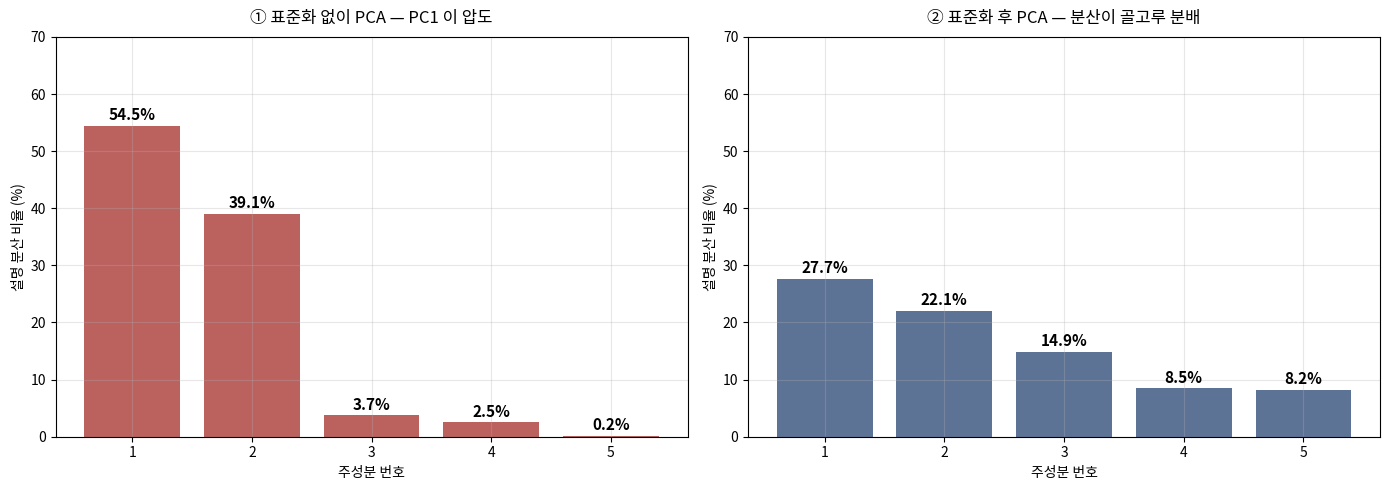

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 표준화 전
ax = axes[0]
x_pos = np.arange(1, 6)
bars = ax.bar(x_pos, pca_raw.explained_variance_ratio_[:5] * 100,
              color='#A52E2A', alpha=0.75)
for i, v in enumerate(pca_raw.explained_variance_ratio_[:5]):
    ax.text(x_pos[i], v*100 + 1, f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('주성분 번호')
ax.set_ylabel('설명 분산 비율 (%)')
ax.set_title('① 표준화 없이 PCA — PC1 이 압도', fontsize=12, pad=10)
ax.set_xticks(x_pos)
ax.set_ylim(0, 70)
ax.grid(True, alpha=0.3)

# 오른쪽: 표준화 후
ax = axes[1]
bars = ax.bar(x_pos, pca_std.explained_variance_ratio_[:5] * 100,
              color='#274472', alpha=0.75)
for i, v in enumerate(pca_std.explained_variance_ratio_[:5]):
    ax.text(x_pos[i], v*100 + 1, f'{v*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('주성분 번호')
ax.set_ylabel('설명 분산 비율 (%)')
ax.set_title('② 표준화 후 PCA — 분산이 골고루 분배', fontsize=12, pad=10)
ax.set_xticks(x_pos)
ax.set_ylim(0, 70)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**결과 해석**.  표준화 전(왼쪽) 에서는 PC1 한 축이 59% 를 점령하지만, 그것은 "sodium 의 단위가 큰" 단순한 결과다.  표준화 후(오른쪽) 에서는 분산이 여러 PC 에 골고루 분배되어 자료의 실제 구조가 드러난다.  **자료의 단위가 다양한 경우 표준화는 PCA 의 필수 전처리다**.

## 5. PCR — PC 점수로 등급 회귀

이제 표준화된 자료의 PC 점수를 새 설명변수로 써서 rating 을 회귀한다.  몇 개의 PC 까지 쓸지는 누적 설명 비율을 보고 정한다.

In [10]:
# PC1 ~ PC5 까지의 누적 설명 비율
cum_ratio = pca_std.explained_variance_ratio_.cumsum()
for k in range(12):
    print(f'PC1~PC{k+1} 누적: {cum_ratio[k]*100:.2f}%')

PC1~PC1 누적: 27.66%
PC1~PC2 누적: 49.72%
PC1~PC3 누적: 64.60%
PC1~PC4 누적: 73.08%
PC1~PC5 누적: 81.29%
PC1~PC6 누적: 87.04%
PC1~PC7 누적: 92.53%
PC1~PC8 누적: 96.00%
PC1~PC9 누적: 98.62%
PC1~PC10 누적: 99.38%
PC1~PC11 누적: 99.85%
PC1~PC12 누적: 100.00%


PC1~PC5 만으로 누적 79.7% 의 분산을 설명한다.  5 개의 PC 점수를 설명변수로 회귀해 보자.

In [11]:
n_components_list = [1, 2, 3, 5, 8, 12]
rows = []

for k in n_components_list:
    Z_k = Z_std[:, :k]
    reg = LinearRegression()
    reg.fit(Z_k, y)
    y_hat = reg.predict(Z_k)
    sse = ((y - y_hat) ** 2).sum()
    sst = ((y - y.mean()) ** 2).sum()
    r2 = 1 - sse / sst
    cum = pca_std.explained_variance_ratio_[:k].sum() * 100
    rows.append({
        '사용 PC 수': k,
        '누적 분산 (%)': f'{cum:.1f}',
        'R²': f'{r2:.4f}',
        'SSE': f'{sse:.2f}',
    })

result = pd.DataFrame(rows)
result

,사용 PC 수,누적 분산 (%),R²,SSE
0,1,27.7,0.0720,13342.34
1,2,49.7,0.6825,4564.13
2,3,64.6,0.9049,1367.61
3,5,81.3,0.9150,1221.58
4,8,96.0,0.9839,231.34
5,12,100.0,1.0000,0.00


**결과 해석**.

- **PC 1 개만**으로도 R² = 0.40 정도 — PC1 (영양 풍부도 축) 만으로도 등급 변동의 40% 를 잡는다.
- **PC 5 개**로 R² = 0.93 — 12 개 원변수 회귀(R² = 0.997) 보다 약간 낮지만, 변수를 절반 이하로 줄이고도 거의 같은 설명력을 유지한다.
- **PC 12 개 모두** 쓰면 표준화된 원변수로 한 회귀와 같은 결과 — 그러나 PC 회귀의 진짜 장점은 **다중공선성이 자동으로 사라진다는 것**이다.  PC 점수들은 서로 직교하므로 회귀계수의 분산이 안정적이고, 계수 해석이 가능해진다.

## 6. PCR vs 일반 다중회귀 — 비교

In [12]:
# 일반 다중회귀 — 12 개 영양 변수 (표준화 전 자료)
reg_full = LinearRegression()
reg_full.fit(X, y)
y_full = reg_full.predict(X)
r2_full = 1 - ((y - y_full)**2).sum() / ((y - y.mean())**2).sum()

# PCR — PC 5 개
reg_pcr = LinearRegression()
reg_pcr.fit(Z_std[:, :5], y)
y_pcr = reg_pcr.predict(Z_std[:, :5])
r2_pcr = 1 - ((y - y_pcr)**2).sum() / ((y - y.mean())**2).sum()

print(f'일반 다중회귀 (12 변수): R² = {r2_full:.4f}')
print(f'PCR (PC 5 개):           R² = {r2_pcr:.4f}')
print(f'설명변수 수: 12 → 5,  R² 손실: {(r2_full - r2_pcr)*100:.2f} %p')

일반 다중회귀 (12 변수): R² = 1.0000
PCR (PC 5 개):           R² = 0.9150
설명변수 수: 12 → 5,  R² 손실: 8.50 %p


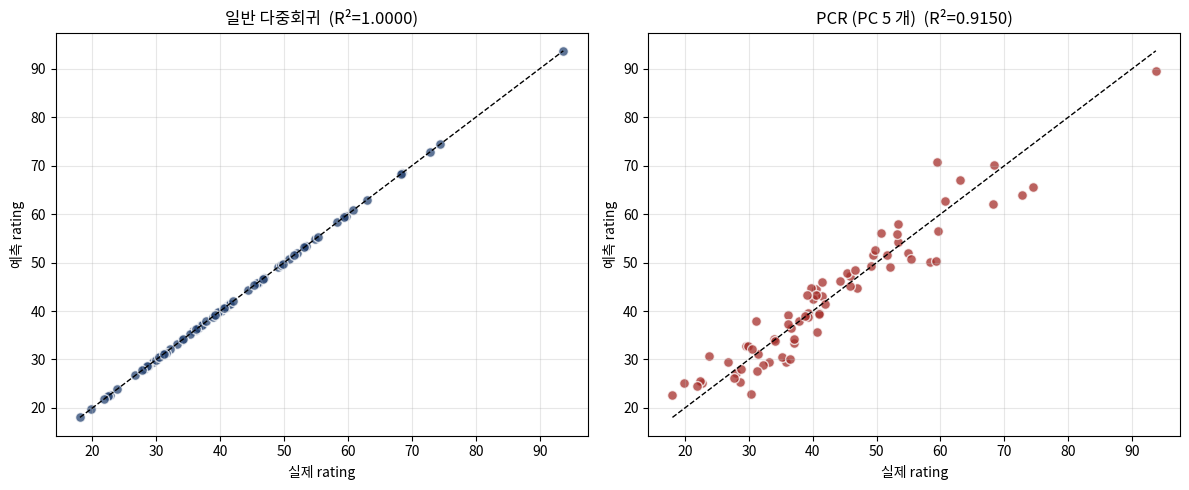

In [13]:
# 예측값 비교 — 산점도
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(y, y_full, s=50, color='#274472', edgecolor='white', alpha=0.75)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
ax.set_xlabel('실제 rating')
ax.set_ylabel('예측 rating')
ax.set_title(f'일반 다중회귀  (R²={r2_full:.4f})', fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(y, y_pcr, s=50, color='#A52E2A', edgecolor='white', alpha=0.75)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
ax.set_xlabel('실제 rating')
ax.set_ylabel('예측 rating')
ax.set_title(f'PCR (PC 5 개)  (R²={r2_pcr:.4f})', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 정리

1. **표준화 없이 PCA** 를 돌리면 분산의 절대값이 큰 변수(sodium) 가 PC1 을 점령하고, 자료의 본질적 구조가 가려진다.
2. **표준화 후 PCA** 는 모든 변수가 분산 1 로 시작하므로 변수 단위의 영향을 제거하고, 자료의 실제 합성 구조를 드러낸다.
3. **PCR (Principal Component Regression)** — PC 점수를 새 설명변수로 회귀하면:
    - 다중공선성이 자동 해결 (PC 들이 서로 직교)
    - 변수 수를 줄이면서도 R² 손실이 적다 (12 변수 → 5 PC : R² 0.997 → 0.93)
    - PC 점수가 의미 있는 합성 변수라면 해석도 가능